In [1]:
import numpy as np

# Parameters
mu_R = 10  # Mean revenue (million)
sigma_R = np.sqrt(2)  # Standard deviation of revenue (million)
mu_C = 8  # Mean costs (million)
sigma_C = np.sqrt(2)  # Standard deviation of costs (million)
r = 0.10  # Discount rate
years = 5  # Time horizon
n_simulations = 10000  # Number of Monte Carlo simulations
rho = 0.80  # Correlation coefficient for part (ii)

# Part (i): Independent revenue and costs
np.random.seed(42)  # For reproducibility
R = np.random.normal(mu_R, sigma_R, (n_simulations, years))
C = np.random.normal(mu_C, sigma_C, (n_simulations, years))
CF = R - C  # Cash flow for each year
discount_factors = (1 + r) ** np.arange(1, years + 1)
NPV = np.sum(CF / discount_factors, axis=1)  # NPV for each simulation

# Part (ii): Correlated revenue and costs
cov_matrix = np.array([[sigma_R**2, rho * sigma_R * sigma_C],
                       [rho * sigma_R * sigma_C, sigma_C**2]])
R_C = np.random.multivariate_normal([mu_R, mu_C], cov_matrix, (n_simulations, years))
R_corr = R_C[:, :, 0]
C_corr = R_C[:, :, 1]
CF_corr = R_corr - C_corr
NPV_corr = np.sum(CF_corr / discount_factors, axis=1)

# Analyze results
def analyze_npv(NPV):
    P10 = np.percentile(NPV, 10)
    P50 = np.percentile(NPV, 50)
    P90 = np.percentile(NPV, 90)
    prob_negative = np.mean(NPV < 0) * 100
    return P10, P50, P90, prob_negative

# Part (i) Results
P10_ind, P50_ind, P90_ind, prob_neg_ind = analyze_npv(NPV)
print("Part (i): Independent Revenue and Costs")
print(f"P10 NPV: {P10_ind:.2f} million")
print(f"P50 NPV: {P50_ind:.2f} million")
print(f"P90 NPV: {P90_ind:.2f} million")
print(f"Probability of Negative NPV: {prob_neg_ind:.2f}%")

# Part (ii) Results
P10_corr, P50_corr, P90_corr, prob_neg_corr = analyze_npv(NPV_corr)
print("\nPart (ii): Correlated Revenue and Costs (ρ = 0.80)")
print(f"P10 NPV: {P10_corr:.2f} million")
print(f"P50 NPV: {P50_corr:.2f} million")
print(f"P90 NPV: {P90_corr:.2f} million")
print(f"Probability of Negative NPV: {prob_neg_corr:.2f}%")

Part (i): Independent Revenue and Costs
P10 NPV: 3.15 million
P50 NPV: 7.56 million
P90 NPV: 12.05 million
Probability of Negative NPV: 1.48%

Part (ii): Correlated Revenue and Costs (ρ = 0.80)
P10 NPV: 5.65 million
P50 NPV: 7.60 million
P90 NPV: 9.57 million
Probability of Negative NPV: 0.00%


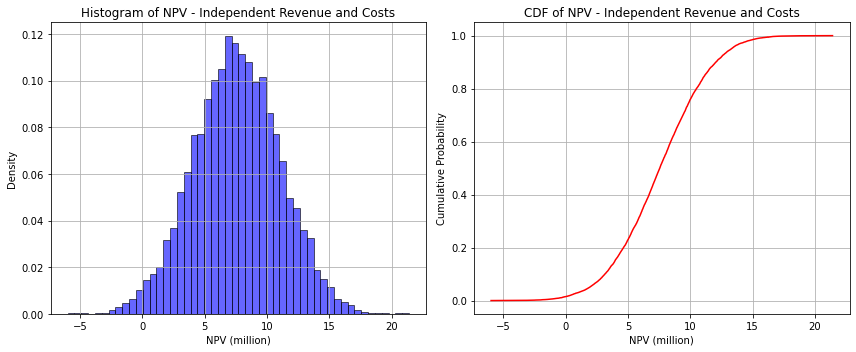

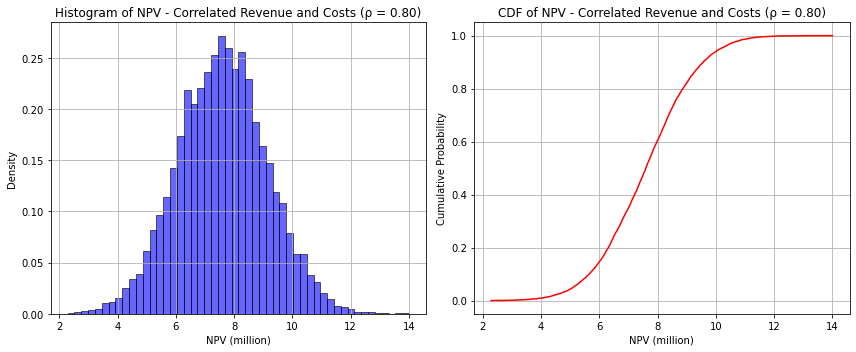

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu_R = 10  # Mean revenue (million)
sigma_R = np.sqrt(2)  # Standard deviation of revenue (million)
mu_C = 8  # Mean costs (million)
sigma_C = np.sqrt(2)  # Standard deviation of costs (million)
r = 0.10  # Discount rate
years = 5  # Time horizon
n_simulations = 10000  # Number of Monte Carlo simulations
rho = 0.80  # Correlation coefficient for part (ii)

# Part (i): Independent revenue and costs
np.random.seed(42)  # For reproducibility
R = np.random.normal(mu_R, sigma_R, (n_simulations, years))
C = np.random.normal(mu_C, sigma_C, (n_simulations, years))
CF = R - C  # Cash flow for each year
discount_factors = (1 + r) ** np.arange(1, years + 1)
NPV = np.sum(CF / discount_factors, axis=1)  # NPV for each simulation

# Part (ii): Correlated revenue and costs
cov_matrix = np.array([[sigma_R**2, rho * sigma_R * sigma_C],
                       [rho * sigma_R * sigma_C, sigma_C**2]])
R_C = np.random.multivariate_normal([mu_R, mu_C], cov_matrix, (n_simulations, years))
R_corr = R_C[:, :, 0]
C_corr = R_C[:, :, 1]
CF_corr = R_corr - C_corr
NPV_corr = np.sum(CF_corr / discount_factors, axis=1)

# Plot Histogram and CDF
def plot_histogram_cdf(NPV, title):
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(NPV, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black')
    plt.title(f'Histogram of NPV - {title}')
    plt.xlabel('NPV (million)')
    plt.ylabel('Density')
    plt.grid(True)

    # CDF
    plt.subplot(1, 2, 2)
    sorted_NPV = np.sort(NPV)
    cdf = np.arange(1, len(sorted_NPV) + 1) / len(sorted_NPV)
    plt.plot(sorted_NPV, cdf, color='red')
    plt.title(f'CDF of NPV - {title}')
    plt.xlabel('NPV (million)')
    plt.ylabel('Cumulative Probability')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot for Part (i): Independent Revenue and Costs
plot_histogram_cdf(NPV, "Independent Revenue and Costs")

# Plot for Part (ii): Correlated Revenue and Costs
plot_histogram_cdf(NPV_corr, "Correlated Revenue and Costs (ρ = 0.80)")